this is the most simplest practical explanation of chain rule

In [ ]:
import numpy as np

x = 2.0
y = 10.0
w = 3.0
b = 1.0
lr = 0.1

print('forward pass')
z = (x *w) + b
prediction = z #linear acitvation
loss = (prediction - y) ** 2

print(f'input (x): {x}')
print(f"weight (w): {w}")
print(f"bias (b): {b}")
print(f"prediction (f(x)): {prediction}")
print(f"target (y): {y}")
print(f"loss (L): {loss}")

print('\n backward pass now')

d_loss_d_pred = 2 * (prediction - y)
print(f"1. dLoss/dPred: {d_loss_d_pred}")

#part2 dPrediction/dZ
d_pred_d_z = 1.0 #cuz derivative of z is 1.0
print(f"2. dPred/dZ: {d_pred_d_z}")

#part3 dLoss/dW
d_z_d_w = x #cuz derivative of (x*w + b) w.r.t w is x
print(f"3. dZ/dW: {d_z_d_w}")


#combine using chain rule:

gradient = d_loss_d_pred * d_pred_d_z * d_z_d_w
print(f"total gradient: {gradient}")

#update the weights

w_new = w - (lr * gradient)
print(f'old weight: {w}')
print(f'new weight: {w_new}')

#check new loss
z_new = (x * w_new) + b
loss_new = (z_new - y)  ** 2
print(f"prediction: {z_new}")
print(f"new loss: {loss_new}")

forward pass
input (x): 2.0
weight (w): 3.0
bias (b): 1.0
prediction (f(x)): 7.0
target (y): 10.0
loss (L): 9.0

 backward pass now
1. dLoss/dPred: -6.0
2. dPred/dZ: 1.0
3. dZ/dW: 2.0
total gradient: -12.0
old weight: 3.0
new weight: 4.2
prediction: 9.4
new loss: 0.3599999999999996


lets understand it more deeply


In [ ]:
import numpy as np

def sigmoid(x):
  """
    The Sigmoid function squashes values between 0 and 1.
    Formula: 1 / (1 + e^-x)
    """
  return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
  """
    The derivative of the Sigmoid function.
    This is crucial for the Chain Rule.
    Formula: sigmoid(x) * (1 - sigmoid(x))
    """
  s = sigmoid(x)
  return s * (1-s)


# Let's create a simple dataset (XOR problem is hard for 1 layer,
# so we use a simple linearly separable example for clarity)
# Input: 2 features, Output: 1 label (0 or 1)
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

# Target: Logical AND operation (only 1 if both inputs are 1)
y = np.array([[0],
              [0],
              [0],
              [1]])


print(x)
print(y)


#lets initialize the model

np.random.seed(42)

#weights connecting input --> hidden layer (2X3)matrix
weights_input_hidden = np.random.randn(2,3)
bias_hidden = np.random.randn(1,3)

#weights connecting hidden --> output (3X1) matrix
weights_output = np.random.randn(3,1)
bias_output = np.random.randn(1,1)

learning_rate = 0.1
epochs = 10000

#training

for epoch in range(epochs):

  #forward pass

  #1. input to hidden
  #Z1 = (X * W1) + B1
  z_hidden = np.dot(X,weights_input_hidden) + bias_hidden
  #A1 = sigmoid(Z1)
  a_hidden = sigmoid(z_hidden)

  #2. output layer
  #Z2 = (A1 * W2) + B2
  z_output = np.dot(a_hidden,weights_output) + bias_output
  #A2 = sigmoid(Z2)
  a_output = sigmoid(z_output)

  #calculating loss (MSE)
  #loss = 1/N * sum((predicted - actual)^2)
  loss = np.mean((a_output - y)**2)

  #backward pass

  #1. output layer gradients
  #dLoss/dOutput = 2 * (predicted - actual) / N (derivative of MSE)
  #however for effieciency we will add sigmoid derivative:
  #dLoss/dZ2 = (A2-Y) * sigmoid_derivative(Z2)
  d_output = (a_output - y) * sigmoid_derivative(z_output)

  #we need to propagate the error back
  #dLoaa/dA1 = dLoss/dZ2 * weights2.T
  #dLoss/dZ1 = dLoaa/dA1 * sigmoid_derivative(Z1)
  d_hidden = np.dot(d_output,weights_output.T) * sigmoid_derivative(z_hidden) #we did transposed because we sent the error back

  #calculating gradient for weights and biases
  #dLoss/dW2 = A1.T * d_output
  grad_weights_hidden_output = np.dot(a_hidden.T, d_output)
  grad_bias_output = np.sum(d_output, axis=0,keepdims=True)

  #dLoss/dW1 = X.T * d_hidden
  grad_weights_input_hidden = np.dot(X.T, d_hidden)
  grad_bias_hidden = np.sum(d_hidden,axis=0,keepdims=True)

  #weight update (gradient descent)
  #Wnew = Wold - (learning_rate * gradient)
  weights_output = weights_output - (learning_rate * grad_weights_hidden_output)
  bias_output = bias_output - (learning_rate * grad_bias_output)

  weights_input_hidden = weights_input_hidden - (learning_rate * grad_weights_input_hidden)

  #logging
  if epoch % 1000 == 0:
    print(f"epoch {epoch}, loss:{loss:.4f}")


#testing:

print("\nFinal Predictions:")
z_hidden = np.dot(X, weights_input_hidden) + bias_hidden
a_hidden = sigmoid(z_hidden)
z_output = np.dot(a_hidden, weights_output) + bias_output
predictions = sigmoid(z_output)
print(np.round(predictions, 3))
print("\nTargets:")
print(y)

2.0
[[0]
 [0]
 [0]
 [1]]
epoch 0, loss:0.2793
epoch 1000, loss:0.0910
epoch 2000, loss:0.0463
epoch 3000, loss:0.0187
epoch 4000, loss:0.0087
epoch 5000, loss:0.0051
epoch 6000, loss:0.0035
epoch 7000, loss:0.0026
epoch 8000, loss:0.0020
epoch 9000, loss:0.0016

Final Predictions:
[[0.006]
 [0.036]
 [0.036]
 [0.947]]

Targets:
[[0]
 [0]
 [0]
 [1]]


now let's build the neural network from scratch


Final Predictions:
 [[0.02]
 [0.98]
 [0.99]
 [0.02]]

W1:
 [[ 4.655  0.679  1.982  6.563]
 [ 4.181 -2.321  2.071  6.773]]

W2:
 [[-10.165]
 [  1.314]
 [ -0.119]
 [  9.89 ]]


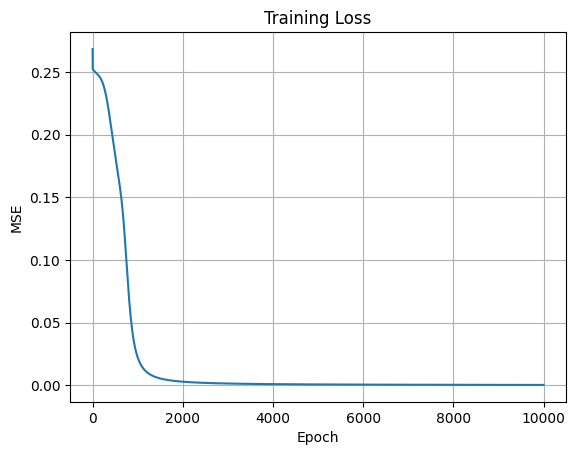

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0,0],
             [0,1],
             [1,0],
             [1,1]])
y = np.array([[0],[1],[1],[0]])

epochs = 10000
lr = 0.5
input_dim,hidden_dim,output_dim = 2,4,1

#initialize weights and biases
np.random.seed(42)
W1 = np.random.randn(input_dim,hidden_dim) * np.sqrt(2.0/input_dim) #we multiplied by np.sqrt to prevent vanishing gradients
b1 = np.zeros((1,hidden_dim))
W2 = np.random.randn(hidden_dim,output_dim) * np.sqrt(2.0/hidden_dim)
# The bias for the output layer (b2) was missing. Added initialization.
b2 = np.zeros((1,output_dim))

#activations
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
  return a * (1-a)

loss_history = []

for epoch in range(epochs):

  #forward pass
  z1 = X @ W1 + b1   #linear: (4,2) @ (2,4) --> (4,4)
  a1 = sigmoid(z1) #activation
  z2 = a1 @ W2 + b2   #linear: (4,4) @ (4,1) --> (4,1)
  a2 = sigmoid(z2)

  #loss function (MSE)
  loss = np.mean((a2 - y)**2)
  loss_history.append(loss)

  # ==========================================
# BACKWARD PASS: CHAIN RULE IMPLEMENTED STEP-BY-STEP
# We split the chain rule into two steps per layer for:
# 1. SHAPE COMPATIBILITY: Matrices must align (rows, cols) for '@' (matrix multiply)
# 2. GRADIENT REUSE: 'dz' is needed for dW, db, and passing error to the previous layer
# ==========================================

# --- OUTPUT LAYER (Layer 2) ---
# STEP 1: Compute ∂L/∂z2 (Error at pre-activation)
# Chain Rule: ∂L/∂z2 = (∂L/∂a2) × (∂a2/∂z2)
# Math: (a2 - y) is ∂L/∂a2 for MSE. sigmoid_derivative(a2) is ∂a2/∂z2.
# 'dz2' IS your first two chain rule terms multiplied. Shape: (4, 1)
dz2 = (a2 - y) * sigmoid_derivative(a2)

# STEP 2: Compute ∂L/∂W2 (Gradient for output weights)
# Chain Rule: ∂L/∂W2 = (∂L/∂z2) × (∂z2/∂W2)
# Since z2 = a1 @ W2 + b2, then ∂z2/∂W2 = a1.T
# Why '@' and .T? Matrix multiply needs inner dims to match: (4, 4).T @ (4, 1) → (4, 1) matches W2.
# This completes your full 3-term chain rule for W2.
dW2 = a1.T @ dz2

# STEP 3: Compute ∂L/∂b2 (Gradient for output bias)
# Bias is added to EVERY sample in the batch. To get the total gradient, we SUM across the batch (axis=0).
# keepdims=True preserves shape (1, 1) so it broadcasts correctly during updates.
db2 = np.sum(dz2, axis=0, keepdims=True)

# --- PROPAGATE ERROR BACK TO HIDDEN LAYER ---
# Chain Rule: ∂L/∂a1 = (∂L/∂z2) × (∂z2/∂a1)
# Since z2 = a1 @ W2, then ∂z2/∂a1 = W2.T
# '@' distributes the single-output error back to all 4 hidden neurons.
# Result 'da1' tells us how much EACH hidden neuron contributed to the final error. Shape: (4, 4)
da1 = dz2 @ W2.T

# --- HIDDEN LAYER (Layer 1) ---
# STEP 1: Compute ∂L/∂z1 (Error at hidden pre-activation)
# Chain Rule: ∂L/∂z1 = (∂L/∂a1) × (∂a1/∂z1)
# We use element-wise '*' because each neuron's activation slope is computed independently.
# 'dz1' is now the fully propagated error signal at the hidden layer. Shape: (4, 4)
dz1 = da1 * sigmoid_derivative(a1)

# STEP 2: Compute ∂L/∂W1 (Gradient for hidden weights)
# Chain Rule: ∂L/∂W1 = X.T @ (∂L/∂z1)
# Transpose X to align shapes: (2, 4).T @ (4, 4) → (2, 4) matches W1 shape.
dW1 = X.T @ dz1

# STEP 3: Compute ∂L/∂b1 (Gradient for hidden bias)
# Same logic as db2: sum over batch, keep shape (1, 4) for direct subtraction during updates.
db1 = np.sum(dz1, axis=0, keepdims=True)

# ==========================================
# GRADIENT DESCENT UPDATE
# Formula: θ_new = θ_old - lr × (∂L/∂θ)
# We subtract because the gradient points UPHILL (higher error). We want DOWNHILL.
# ==========================================
W2 -= lr * dW2  # Update output weights
b2 -= lr * db2  # Update output bias
W1 -= lr * dW1  # Update hidden weights
b1 -= lr * db1  # Update hidden bias

#output

print("Final Predictions:\n", np.round(a2, 2))
print("\nW1:\n", np.round(W1, 3))
print("\nW2:\n", np.round(W2, 3))

plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()
plt.show()